In [1]:
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import matplotlib
import sys
import cupy as cp
import cupyx.scipy.ndimage as ndi  # GPU-accelerated ndimage
# from cupyx.scipy.interpolate import LinearNDInterpolator
from cupyx.scipy.ndimage import gaussian_filter, uniform_filter

from scipy.interpolate import griddata
from scipy.ndimage import zoom
from time import time
from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
from scipy.optimize import minimize, differential_evolution

In [20]:
# specific_name = "qiskit_codes"
specific_name = "qiskit_experiments"
folder = f"C:/Users/Ivo/Documents/{specific_name}/data/kyiv/14/power_broadening (narrowing)"
folder_sim = f"C:/Users/Ivo/Documents/{specific_name}/sims/time_dep"
which_plots = 1

if which_plots == 0:
    folders = [f"{folder}/lz1_pulses/2024-12-29",
               f"{folder}/lz4_pulses/2024-12-30",
               f"{folder}/lz8_pulses/2024-12-30",
               f"{folder_sim}/lz1_pulses/2025-10-07"]
elif which_plots == 1:
    folders = [f"{folder}/ae1_pulses/2024-12-30",
               f"{folder}/ae4_pulses/2024-12-30",
               f"{folder}/ae8_pulses/2024-12-30",
               f"{folder_sim}/ae8_pulses/2025-10-07"]
elif which_plots == 2:
    folders = [f"{folder}/hae1_pulses/2024-12-30",
               f"{folder}/hae4_pulses/2024-12-30",
               f"{folder}/hae8_pulses/2024-12-30",
               f"{folder_sim}/hae8_pulses/2025-10-07"]
times = []
for folder in folders:
    times_folder = [folder + '/' + os.listdir(folder)[-1]]
    times.extend(times_folder)
print(times)


['C:/Users/Ivo/Documents/qiskit_experiments/data/kyiv/14/power_broadening (narrowing)/ae1_pulses/2024-12-30/005040', 'C:/Users/Ivo/Documents/qiskit_experiments/data/kyiv/14/power_broadening (narrowing)/ae4_pulses/2024-12-30/010956', 'C:/Users/Ivo/Documents/qiskit_experiments/data/kyiv/14/power_broadening (narrowing)/ae8_pulses/2024-12-30/012249', 'C:/Users/Ivo/Documents/qiskit_experiments/sims/time_dep/ae8_pulses/2025-10-07/114940']


In [21]:
if which_plots == 1:
    l, p, x0 = 573.692297386677,0.2271200201666013,0.0012287080262098 # 800
    T = 800 * 2e-9 / 9
elif which_plots in [0, 2]:
    l, p, x0 = 240.31017602118783,0.273639040773091,0.0020544076252577 # 400
    T = 400 * 2e-9 / 9
tr_probs, dets, amps = [], [], []
for t in times:
    files = os.listdir(t)
    f1 = [f for f in files if f.endswith("tr_prob.pkl")][0]
    f2 = [f for f in files if f.endswith("detunings.pkl")][0]
    f3 = [f for f in files if f.endswith("areas.pkl")][0]
    with open(os.path.join(t, f1), "rb") as f1:
        tr_probs.append(pickle.load(f1))
    with open(os.path.join(t, f2), "rb") as f2:
        dets.append(pickle.load(f2) * 1e9 / 1e6)
    with open(os.path.join(t, f3), "rb") as f3:
        amps.append(l * (1 - np.exp(- p * (pickle.load(f3) - x0))) / (1e6 * T))
tr_probs[-1] = tr_probs[-1].T

### A calculation of similarity between plots

In [4]:
def interpolate_to_dpi(x, y, z, new_dpi=10000):
    """
    Interpolates the 2D data to a consistent DPI/grid using linear interpolation.
    
    Args:
        x (np.ndarray): 1D array of x-coordinates.
        y (np.ndarray): 1D array of y-coordinates.
        z (np.ndarray): 2D array of values with shape (len(y), len(x)).
        new_dpi (int): Number of points for the new uniform grid.
    
    Returns:
        tuple: new_x, new_y, new_z (interpolated grids).
    """

    x, y, z = cp.asarray(x), cp.asarray(y), cp.asarray(z)
    
    new_x = cp.linspace(cp.min(x), cp.max(x), new_dpi)
    new_y = cp.linspace(cp.min(y), cp.max(y), new_dpi)
    
    # new_z = resize(z, (new_dpi, new_dpi), order=1)
    input_shape = cp.asarray(z.shape)
    output_shape = cp.asarray([new_dpi, new_dpi])
    factors = cp.divide(input_shape, output_shape)
    zoom_factors = [1 / f for f in factors]
    new_z = ndi.zoom(
        z, zoom_factors, order=1
    )

    return new_x, new_y, new_z

In [5]:
def ssim_cupy(img1, img2, data_range=None, win_size=11, sigma=1.5,
              K1=0.01, K2=0.03, return_map=False):
    """
    SSIM between two 2D arrays on GPU.
    img1, img2: CuPy arrays (H,W) or NumPy arrays (will be moved to GPU)
    data_range: value range (e.g., 1.0 for probabilities, 255 for 8-bit).
                If None, uses max(minmax of both) - min(minmax of both).
    win_size:   odd window size for Gaussian (typically 11)
    sigma:      Gaussian std dev in pixels (typically 1.5)
    return_map: if True, returns (mean_ssim, ssim_map_cp)
    """
    x = cp.asarray(img1, dtype=cp.float32)
    y = cp.asarray(img2, dtype=cp.float32)
    if x.shape != y.shape:
        raise ValueError(f"Shapes must match. Got {x.shape} vs {y.shape}.")

    if data_range is None:
        mx = cp.nanmax(cp.stack([x, y]))
        mn = cp.nanmin(cp.stack([x, y]))
        data_range = float(mx - mn) if float(mx - mn) > 0 else 1.0

    C1 = (K1 * data_range) ** 2
    C2 = (K2 * data_range) ** 2

    # Gaussian window via ndimage; set truncate to match exact win_size
    truncate = ((win_size - 1) / 2) / sigma
    mu_x = gaussian_filter(x, sigma=sigma, mode='reflect', truncate=truncate)
    mu_y = gaussian_filter(y, sigma=sigma, mode='reflect', truncate=truncate)

    mu_x2 = mu_x * mu_x
    mu_y2 = mu_y * mu_y
    mu_xy = mu_x * mu_y

    sigma_x2 = gaussian_filter(x * x, sigma=sigma, mode='reflect', truncate=truncate) - mu_x2
    sigma_y2 = gaussian_filter(y * y, sigma=sigma, mode='reflect', truncate=truncate) - mu_y2
    sigma_xy = gaussian_filter(x * y, sigma=sigma, mode='reflect', truncate=truncate) - mu_xy

    # numerical guard (small negatives from roundoff)
    sigma_x2 = cp.maximum(sigma_x2, 0)
    sigma_y2 = cp.maximum(sigma_y2, 0)

    num1 = 2 * mu_xy + C1
    num2 = 2 * sigma_xy + C2
    den1 = mu_x2 + mu_y2 + C1
    den2 = sigma_x2 + sigma_y2 + C2

    ssim_map = (num1 * num2) / (den1 * den2)
    mean_ssim = float(ssim_map.mean())

    return (mean_ssim, ssim_map) if return_map else mean_ssim


In [6]:
def mean_squared_error(a, b):
    """Custom MSE on GPU using NumPy."""
    diff = a - b
    return float(cp.mean(diff ** 2))


In [7]:
def offset_plots(params, x1, y1, z1, x2, y2, z2):
    x1, y1, z1 = cp.asarray(x1), cp.asarray(y1), cp.asarray(z1)
    x2, y2, z2 = cp.asarray(x2), cp.asarray(y2), cp.asarray(z2)
    
    # Extract parameters
    x_offset, y_offset, \
    x1_lclip, x1_rclip, y1_lclip, y1_rclip, \
    x2_lclip, x2_rclip, y2_lclip, y2_rclip = params
    
    # Find corresponding indices
    x_len, y_len = x2.shape[0], y2.shape[0]
    # x_offset_idx = int(x_offset * x_len)
    # y_offset_idx = int(y_offset * y_len)
    x_offset_idx, y_offset_idx = int(cp.round(x_offset)), int(cp.round(y_offset))
    
    x1_lclip_idx, x1_rclip_idx = int(cp.round(x1_lclip)), int(cp.round(x1_rclip))
    y1_lclip_idx, y1_rclip_idx= int(cp.round(y1_lclip)), int(cp.round(y1_rclip))
    
    x2_lclip_idx, x2_рclip_idx = int(cp.round(x2_lclip)), int(cp.round(x2_rclip))
    y2_lclip_idx, y2_rclip_idx = int(cp.round(y2_lclip)), int(cp.round(y2_rclip))
    
    # Find bounds of new overlap between plots
    x1_lidx, x1_ridx = cp.maximum(x1_lclip, x1_lclip + x_offset_idx), cp.minimum(x_len - x1_rclip, x_len - x1_rclip + x_offset_idx)
    y1_lidx, y1_ridx = cp.maximum(y1_lclip, y1_lclip + y_offset_idx), cp.minimum(y_len - y1_rclip, y_len - y1_rclip + y_offset_idx)
    
    x2_lidx, x2_ridx = cp.maximum(x2_lclip, x2_lclip - x_offset_idx), cp.minimum(x_len - x2_rclip, x_len - x2_rclip - x_offset_idx)
    y2_lidx, y2_ridx = cp.maximum(y2_lclip, y2_lclip - y_offset_idx), cp.minimum(y_len - y2_rclip, y_len - y2_rclip - y_offset_idx)

    # If there is no overlap, penalize
    if (x1_ridx <= x1_lidx) or (y1_ridx <= y1_lidx) or (x2_ridx <= x2_lidx) or (y2_ridx <= y2_lidx):
        return 1e9
    # print("x, y bounds are", x1_lidx, x1_ridx, y1_lidx, y1_ridx, x2_lidx, x2_ridx, y2_lidx, y2_ridx)

    Z1 = z1[x1_lidx : x1_ridx, y1_lidx : y1_ridx]
    Z2 = z2[x2_lidx : x2_ridx, y2_lidx : y2_ridx]
    X1, X2 = x1[x1_lidx : x1_ridx], x2[x2_lidx : x2_ridx]
    Y1, Y2 = y1[y1_lidx : y1_ridx], y2[y2_lidx : y2_ridx]
    
    X1, Y1, Z1 = interpolate_to_dpi(X1, Y1, Z1)
    X2, Y2, Z2 = interpolate_to_dpi(X2, Y2, Z2)

    # return cp.asnumpy(Z1), cp.asnumpy(Z2)
    return Z1, Z2


In [8]:
def loss(params, x1, y1, z1, x2, y2, z2):
    """Loss function used by scipy.minimize."""
    Z1, Z2 = offset_plots(params, x1, y1, z1, x2, y2, z2)
    # print("Shapes of Z1 and Z2 are", Z1.shape, Z2.shape)
    return cp.asnumpy(mean_squared_error(Z2, Z1))
    # return ssim_cupy(Z1, Z2, data_range=1.)


In [9]:
def align_and_calculate_MSE(x1, y1, z1, x2, y2, z2):
    # t = time()
    x1i, y1i, z1i = interpolate_to_dpi(x1, y1, z1)
    x2i, y2i, z2i = interpolate_to_dpi(x2, y2, z2)
    # print("Interpolation completed in", time() - t)
    
    # t_opt = time()
    # Initial params and bounds
    initial_params = [0] * 10
    
    x2_max = float(cp.max(x2i))
    y2_max = float(cp.max(y2i))
    
    bounds = [
        (-500, 500), (-500, 500),
        (0, 500), (0, 500), (0, 500), (0, 500),
        (0, 500), (0, 500), (0, 500), (0, 500),
    ]
    res = minimize(
        loss, initial_params, args=(x1i, y1i, z1i, x2i, y2i, z2i),
        method="Powell", bounds=bounds, options={'maxiter': 2000} 
    )
    # print(res)
    # print("Optimization completed in", time() - t_opt)
    Z1, Z2 = offset_plots(res.x, x1i, y1i, z1i, x2i, y2i, z2i)
    return Z1, Z2

In [13]:
def visualize(Z1, Z2, x1, y1, z1, x2, y2, z2):
    (x1i, y1i, z1i), (x2i, y2i, z2i) = interpolate_to_dpi(x1, y1, z1), interpolate_to_dpi(x2, y2, z2)
    t1 = time()
    diff = cp.asnumpy(Z2 - Z1)
    plt.pcolormesh(diff)
    plt.colorbar()
    print("Plotting completed in", time() - t1)
    
    t2 = time()
    plt.show()
    print("Show completed in", time() - t2)
    print("MSE:", mean_squared_error(Z2, Z1))
    print("Old MSE:", mean_squared_error(z2i, z1i))
    print("SSIM:", ssim_cupy(Z1, Z2, data_range=1))
    print("Old SSIM:", ssim_cupy(z1i, z2i, data_range=1))


In [22]:
Z1_03, Z2_03 = align_and_calculate_MSE(dets[0], amps[0], tr_probs[0], dets[3], amps[3], tr_probs[3])
Z1_13, Z2_13 = align_and_calculate_MSE(dets[1], amps[1], tr_probs[1], dets[3], amps[3], tr_probs[3])
Z1_23, Z2_23 = align_and_calculate_MSE(dets[2], amps[2], tr_probs[2], dets[3], amps[3], tr_probs[3])
Z1_02, Z2_02 = align_and_calculate_MSE(dets[0], amps[0], tr_probs[0], dets[2], amps[2], tr_probs[2])
Z1_12, Z2_12 = align_and_calculate_MSE(dets[1], amps[1], tr_probs[1], dets[2], amps[2], tr_probs[2])
Z1_01, Z2_01 = align_and_calculate_MSE(dets[0], amps[0], tr_probs[0], dets[1], amps[1], tr_probs[1])

Plotting completed in 13.149315357208252


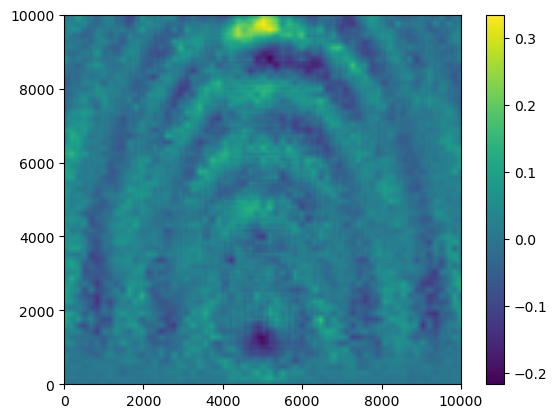

Show completed in 52.82900094985962
MSE: 0.0020942721903784967
Old MSE: 0.0030236302593598012
SSIM: 0.9906224012374878
Old SSIM: 0.9863913059234619


In [14]:
visualize(Z1_03, Z2_03, dets[0], amps[0], tr_probs[0], dets[3], amps[3], tr_probs[3])

Plotting completed in 13.84200382232666


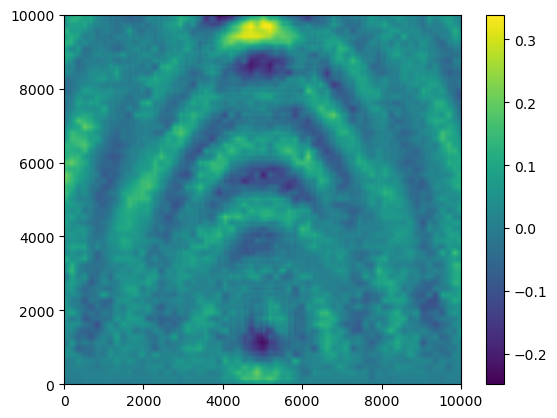

Show completed in 54.22195219993591
MSE: 0.003457476609591093
Old MSE: 0.010688268570085811
SSIM: 0.9855859279632568
Old SSIM: 0.971660315990448


In [15]:
visualize(Z1_13, Z2_13, dets[1], amps[1], tr_probs[1], dets[3], amps[3], tr_probs[3])

Plotting completed in 13.373073816299438


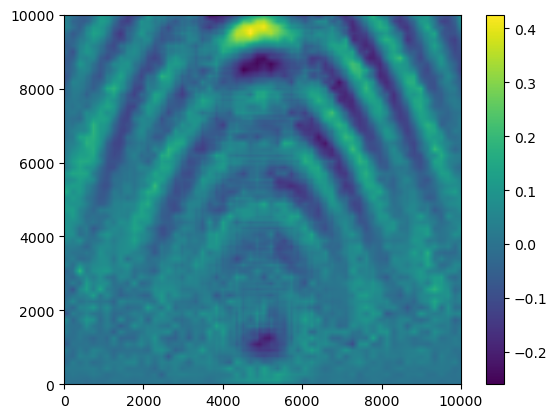

Show completed in 51.958821535110474
MSE: 0.004973676149811295
Old MSE: 0.02038221990554885
SSIM: 0.9849367737770081
Old SSIM: 0.9640313386917114


In [16]:
visualize(Z1_23, Z2_23, dets[2], amps[2], tr_probs[2], dets[3], amps[3], tr_probs[3])

Plotting completed in 12.99599313735962


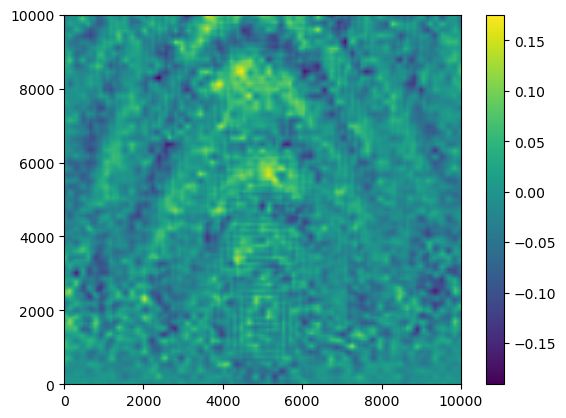

Show completed in 53.193432569503784
MSE: 0.0013887871159864464
Old MSE: 0.015973835470383543
SSIM: 0.9932498931884766
Old SSIM: 0.9694701433181763


In [17]:
visualize(Z1_02, Z2_02, dets[0], amps[0], tr_probs[0], dets[2], amps[2], tr_probs[2])

Plotting completed in 12.482967853546143


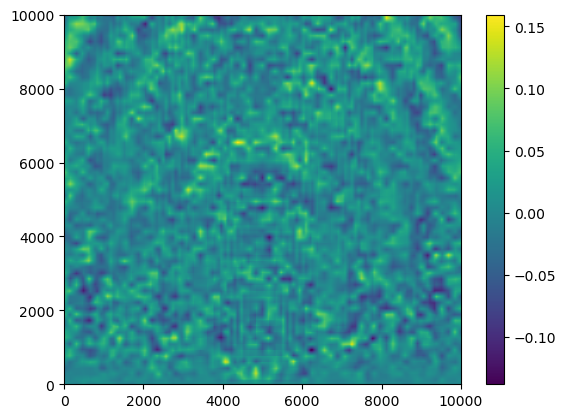

Show completed in 53.46173167228699
MSE: 0.0008101779631435451
Old MSE: 0.010004056928935055
SSIM: 0.994288980960846
Old SSIM: 0.9807500839233398


In [18]:
visualize(Z1_12, Z2_12, dets[1], amps[1], tr_probs[1], dets[2], amps[2], tr_probs[2])

Plotting completed in 13.486286640167236


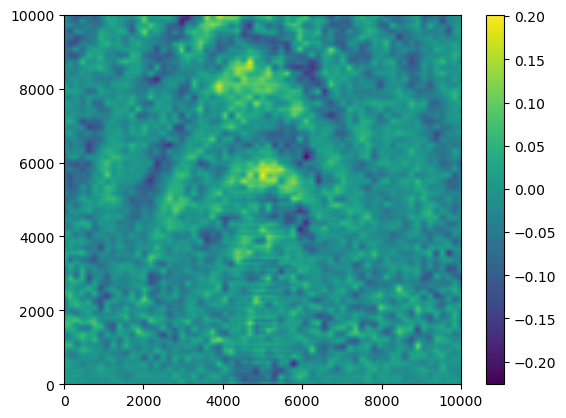

Show completed in 54.66691446304321
MSE: 0.0017181842083391027
Old MSE: 0.005938105343569817
SSIM: 0.991974413394928
Old SSIM: 0.9812530279159546


In [19]:
visualize(Z1_01, Z2_01, dets[0], amps[0], tr_probs[0], dets[1], amps[1], tr_probs[1])

Plotting completed in 19.912966012954712


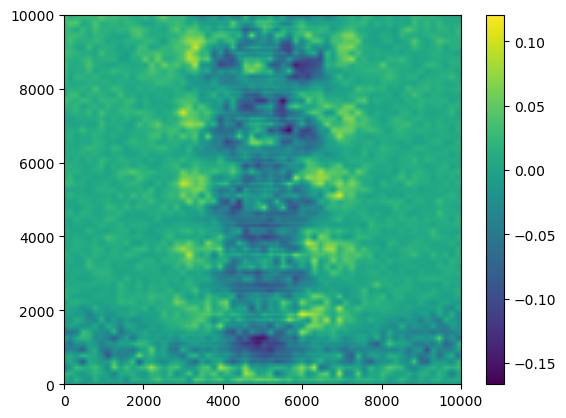

Show completed in 58.48917317390442
MSE: 0.0008217958812057396
Old MSE: 0.0016534549979758451
SSIM: 0.9964900612831116
Old SSIM: 0.9923036694526672


In [23]:
visualize(Z1_03, Z2_03, dets[0], amps[0], tr_probs[0], dets[3], amps[3], tr_probs[3])

Plotting completed in 14.229808568954468


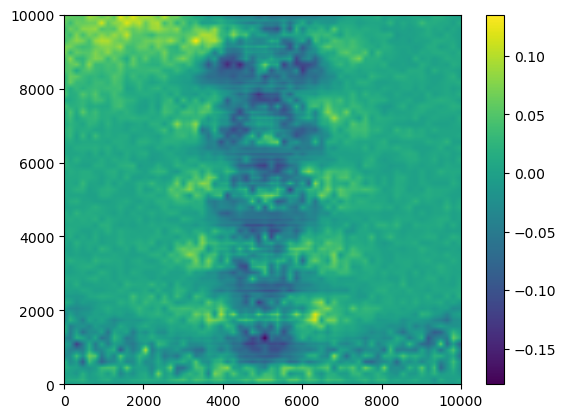

Show completed in 56.967296838760376
MSE: 0.0009968616848621485
Old MSE: 0.001827570244879263
SSIM: 0.9965819120407104
Old SSIM: 0.9921184182167053


In [24]:
visualize(Z1_13, Z2_13, dets[1], amps[1], tr_probs[1], dets[3], amps[3], tr_probs[3])

Plotting completed in 14.59941554069519


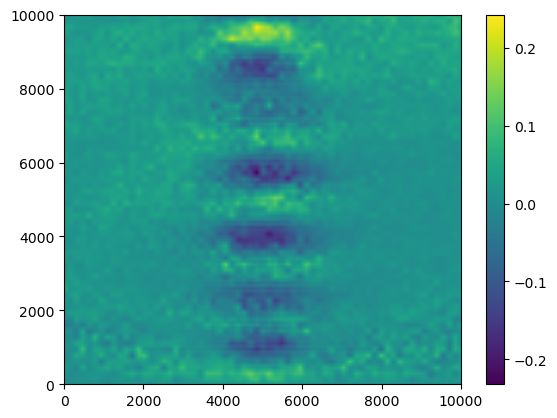

Show completed in 54.06012797355652
MSE: 0.0014682722539111172
Old MSE: 0.007295086079625355
SSIM: 0.9938308596611023
Old SSIM: 0.9775555729866028


In [25]:
visualize(Z1_23, Z2_23, dets[2], amps[2], tr_probs[2], dets[3], amps[3], tr_probs[3])

Plotting completed in 15.93863296508789


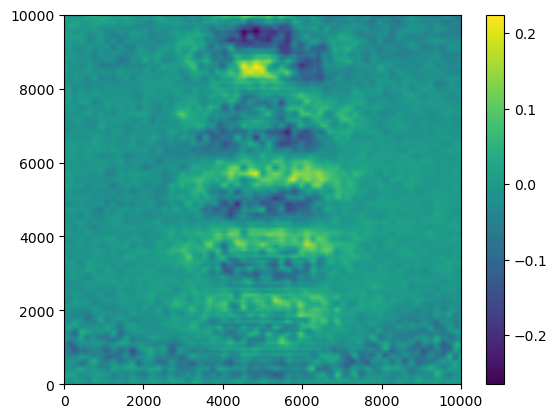

Show completed in 53.63345241546631
MSE: 0.0016250541040944255
Old MSE: 0.005342680536346114
SSIM: 0.9940125346183777
Old SSIM: 0.9854913353919983


In [26]:
visualize(Z1_02, Z2_02, dets[0], amps[0], tr_probs[0], dets[2], amps[2], tr_probs[2])

Plotting completed in 14.911765575408936


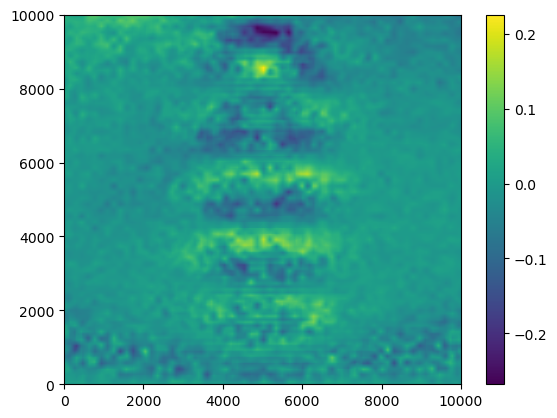

Show completed in 57.09345746040344
MSE: 0.0015164212376275728
Old MSE: 0.0063449802322600385
SSIM: 0.9947817325592041
Old SSIM: 0.9832979440689087


In [27]:
visualize(Z1_12, Z2_12, dets[1], amps[1], tr_probs[1], dets[2], amps[2], tr_probs[2])

Plotting completed in 14.17691421508789


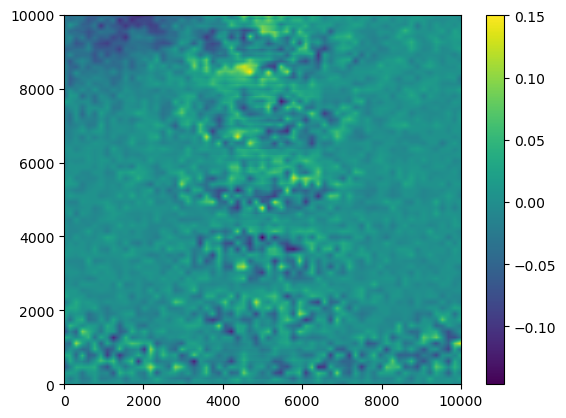

Show completed in 55.49368929862976
MSE: 0.0004963289390438041
Old MSE: 0.000579505049184029
SSIM: 0.9972682595252991
Old SSIM: 0.9967600107192993


In [28]:
visualize(Z1_01, Z2_01, dets[0], amps[0], tr_probs[0], dets[1], amps[1], tr_probs[1])